# Experiment 9: Skill Demand Trajectory — What's Rising vs. Dying (2023 → 2025 → 2026)

**Research question:** Which data science skills are growing in employer demand, and which are being commoditized or replaced — and does a skill's current salary premium reflect its trajectory?

**Why it matters:** Experiment 7 tells you which skills pay the most *today*. This experiment adds the time dimension: a skill with a high premium but declining demand may be scarce (rewarded now, but a shrinking market), while a skill with a low premium but rapidly rising demand is being commoditized before salaries catch up. Knowing the trajectory changes which skills are actually worth learning.

**Approach:** Compute skill prevalence (% of postings mentioning each skill) separately for each dataset cohort (glassdoor_2023, data_science_job_posts_2025, our_own_dataset ≈ 2026). Then rank skills by momentum score and plot rising vs. dying quadrants.

**Datasets used:** All three sources via `build_unified_jobs_df()`, distinguished by `source_dataset`.

**Important caveat:** The three cohorts differ in composition (geography, role mix, scrape methodology). Prevalence shifts partly reflect dataset differences, not only true market change. We control for this by restricting to data-science-adjacent roles and noting the caveat in conclusions.

## Outputs for report

* (1) Variable / Inputs: Skill prevalence (% of postings mentioning each skill) computed per cohort year (2023, 2025, 2026) across all unified job postings filtered to data-science-adjacent roles.
* (2) Model (max 10 words): Prevalence trend and momentum score across three cohort years.
* (3) Finding Statement (max 15 words): Generative AI and cloud skills are rising; traditional BI tools show declining demand.
* (4) Limitation or Extension (max 30 words): Cohorts differ in geography and scrape methodology, so prevalence shifts partly reflect dataset composition rather than pure market change; a controlled longitudinal sample would strengthen causal claims.

In [1]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import pandas as pd
from scipy import stats

from helpers import SKILL_PATTERNS
from job_dataset_union import build_unified_jobs_df

In [2]:
ROLE_BUCKET_PATTERNS = [
    ("data_scientist",    r"\b(data scientist|decision scientist|applied scientist|research scientist)\b"),
    ("machine_learning",  r"\b(machine learning engineer|ml engineer|ai engineer|artificial intelligence engineer|llm engineer)\b"),
    ("data_engineer",     r"\bdata engineer\b"),
    ("analyst_bi",        r"\b(data analyst|business intelligence|bi analyst|analytics engineer|analyst)\b"),
    ("statistician",      r"\b(statistician|statistical)\b"),
]

COHORT_LABEL = {
    "glassdoor_2023":              "2023",
    "data_science_job_posts_2025": "2025",
    "our_own_dataset":             "2026",
}

MIN_COHORT_ROWS = 50   # drop a cohort/skill combo if fewer than this many rows


def assign_role_bucket(title):
    title = str(title).lower()
    for label, pattern in ROLE_BUCKET_PATTERNS:
        if __import__('re').search(pattern, title):
            return label
    return "other"

## 1) Load and label cohorts

In [3]:
df = build_unified_jobs_df().copy()

df["cohort"] = df["source_dataset"].map(COHORT_LABEL)
df["role_bucket"] = df["job_title"].fillna("").apply(assign_role_bucket)
df["desc"] = df["job_description_skills"].fillna("").astype(str)

# Keep only rows with a recognised role and non-empty description
analysis_df = df[
    (df["role_bucket"] != "other") &
    (df["desc"].str.strip() != "")
].copy()

print(f"Total rows loaded          : {len(df)}")
print(f"Rows after role/desc filter: {len(analysis_df)}")
print()
print("Cohort breakdown:")
print(analysis_df["cohort"].value_counts().sort_index().to_string())
print()
print("Role breakdown:")
print(analysis_df["role_bucket"].value_counts().to_string())

Total rows loaded          : 7444
Rows after role/desc filter: 5125

Cohort breakdown:
cohort
2023    1270
2025     941
2026    2914

Role breakdown:
role_bucket
data_scientist      2838
analyst_bi          1021
data_engineer        711
machine_learning     555


## 2) Compute skill prevalence per cohort

In [4]:
cohort_order = ["2023", "2025", "2026"]
cohort_sizes = analysis_df["cohort"].value_counts()

prevalence_records = []

for cohort in cohort_order:
    subset = analysis_df[analysis_df["cohort"] == cohort]
    n = len(subset)
    if n < MIN_COHORT_ROWS:
        print(f"Skipping cohort {cohort}: only {n} rows (< {MIN_COHORT_ROWS})")
        continue
    for skill, pattern in SKILL_PATTERNS.items():
        count = subset["desc"].str.contains(pattern, case=False, regex=True).sum()
        prevalence_records.append({
            "cohort": cohort,
            "skill": skill,
            "count": int(count),
            "n": n,
            "prevalence_pct": count / n * 100,
        })

prev_df = pd.DataFrame(prevalence_records)

# Pivot so rows = skills, columns = cohort years
pivot = prev_df.pivot(index="skill", columns="cohort", values="prevalence_pct").reindex(columns=cohort_order)
pivot_counts = prev_df.pivot(index="skill", columns="cohort", values="count").reindex(columns=cohort_order)

print("Prevalence (%) per skill per cohort — top 20 by 2026 prevalence:")
print(pivot.sort_values("2026", ascending=False).head(20).round(1).to_string())

Prevalence (%) per skill per cohort — top 20 by 2026 prevalence:
cohort                 2023  2025  2026
skill                                  
Python                 12.1  67.8  58.9
SQL                     6.9  47.0  53.6
Machine Learning       30.7  61.6  45.0
ETL                     4.7   0.0  31.6
R                       7.9  36.3  30.6
Business Intelligence   4.7   0.0  29.9
AWS                     2.7  23.1  28.1
Data Visualization     10.9   0.0  27.0
Communication           6.7   0.0  24.0
Generative AI           1.3   0.0  23.9
Azure                   0.7  16.4  23.0
Statistics             24.8   0.0  22.3
GCP                     0.5  11.2  20.0
Power BI                1.0   2.7  19.6
Spark                   1.7  17.1  17.1
Tableau                 4.1  12.3  16.5
API                     0.9   0.0  16.4
Optimization            4.3   0.0  14.4
A/B Testing             3.1   0.0  14.4
Git                     2.4   6.8  13.7


## 3) Compute momentum scores

For each skill we compute:
- **absolute_change**: prevalence in 2026 minus prevalence in 2023 (percentage points)
- **relative_change**: absolute_change / (2023 prevalence + 1) — avoids division by zero for new skills
- **momentum_score**: weighted average favouring the most recent interval (2025→2026 weighted 2×, 2023→2025 weighted 1×)

In [5]:
available_cohorts = [c for c in cohort_order if c in pivot.columns]

momentum = pd.DataFrame(index=pivot.index)

for c in cohort_order:
    if c in pivot.columns:
        momentum[f"prev_{c}"] = pivot[c]

if "2023" in available_cohorts and "2026" in available_cohorts:
    momentum["absolute_change_pp"] = momentum["prev_2026"] - momentum["prev_2023"]
    momentum["relative_change_pct"] = momentum["absolute_change_pp"] / (momentum["prev_2023"] + 1) * 100

# Momentum: recent interval weighted more heavily
if all(c in available_cohorts for c in ["2023", "2025", "2026"]):
    delta_early = momentum["prev_2025"] - momentum["prev_2023"]
    delta_late  = momentum["prev_2026"] - momentum["prev_2025"]
    momentum["momentum_score"] = (delta_early * 1 + delta_late * 2) / 3
elif "2023" in available_cohorts and "2026" in available_cohorts:
    momentum["momentum_score"] = momentum["absolute_change_pp"]

momentum = momentum.sort_values("momentum_score", ascending=False)

print("Top 15 rising skills (by momentum score):")
print(momentum.head(15).round(2).to_string())
print()
print("Top 15 declining skills (by momentum score):")
print(momentum.tail(15).sort_values("momentum_score").round(2).to_string())

Top 15 rising skills (by momentum score):
                       prev_2023  prev_2025  prev_2026  absolute_change_pp  relative_change_pct  momentum_score
skill                                                                                                          
ETL                         4.72       0.00      31.57               26.85               469.00           19.47
Business Intelligence       4.72       0.00      29.92               25.20               440.22           18.37
SQL                         6.93      46.97      53.60               46.67               588.64           17.77
Generative AI               1.34       0.00      23.88               22.55               964.09           15.48
Data Visualization         10.87       0.00      26.97               16.11               135.74           14.36
Communication               6.69       0.00      23.95               17.26               224.37           13.74
Python                     12.13      67.80      58.89        

## 4) Visuals

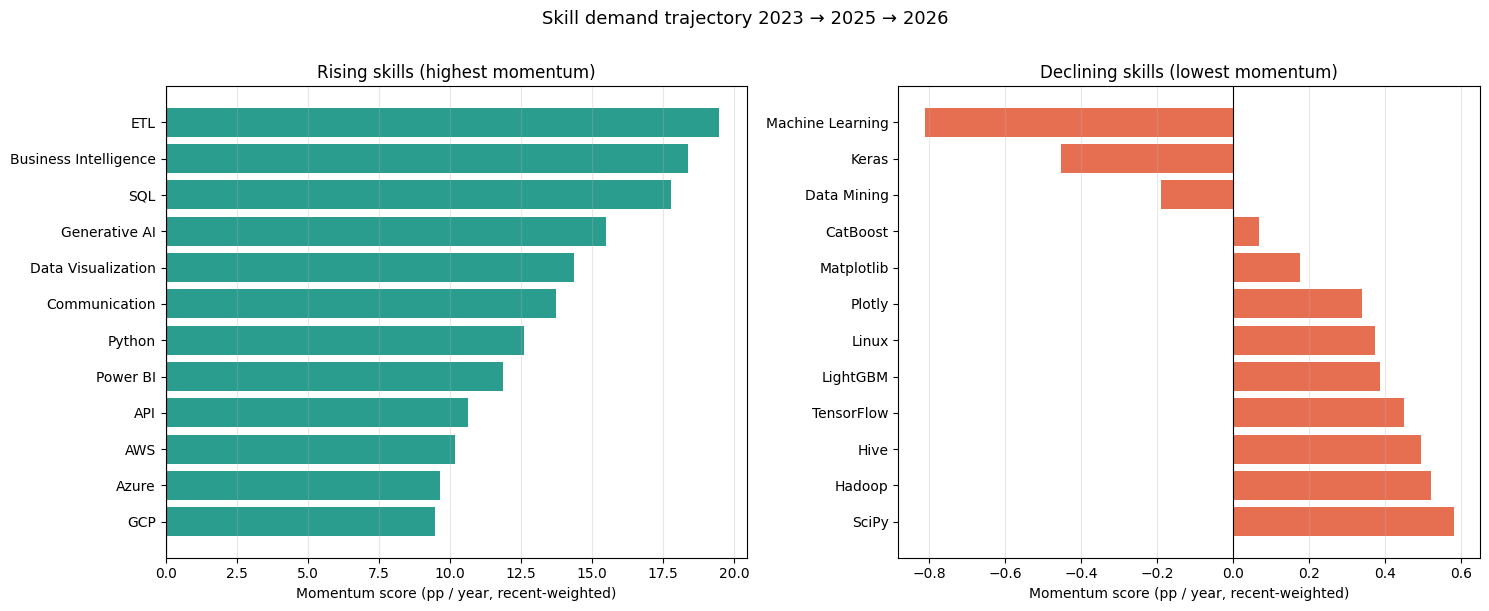

In [6]:
# ── Plot 1: Top rising and top declining skills (horizontal bar) ──────────────
n_show = 12
top_rising   = momentum.head(n_show).copy()
top_declining = momentum.tail(n_show).sort_values("momentum_score").copy()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].barh(top_rising.index[::-1], top_rising["momentum_score"][::-1], color="#2a9d8f")
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_title("Rising skills (highest momentum)")
axes[0].set_xlabel("Momentum score (pp / year, recent-weighted)")
axes[0].grid(True, axis="x", alpha=0.3)

axes[1].barh(top_declining.index[::-1], top_declining["momentum_score"][::-1], color="#e76f51")
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Declining skills (lowest momentum)")
axes[1].set_xlabel("Momentum score (pp / year, recent-weighted)")
axes[1].grid(True, axis="x", alpha=0.3)

plt.suptitle("Skill demand trajectory 2023 → 2025 → 2026", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

C:\Users\slurm\AppData\Local\Temp\ipykernel_25920\2380979263.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors_rising   = cm.get_cmap("tab10").colors


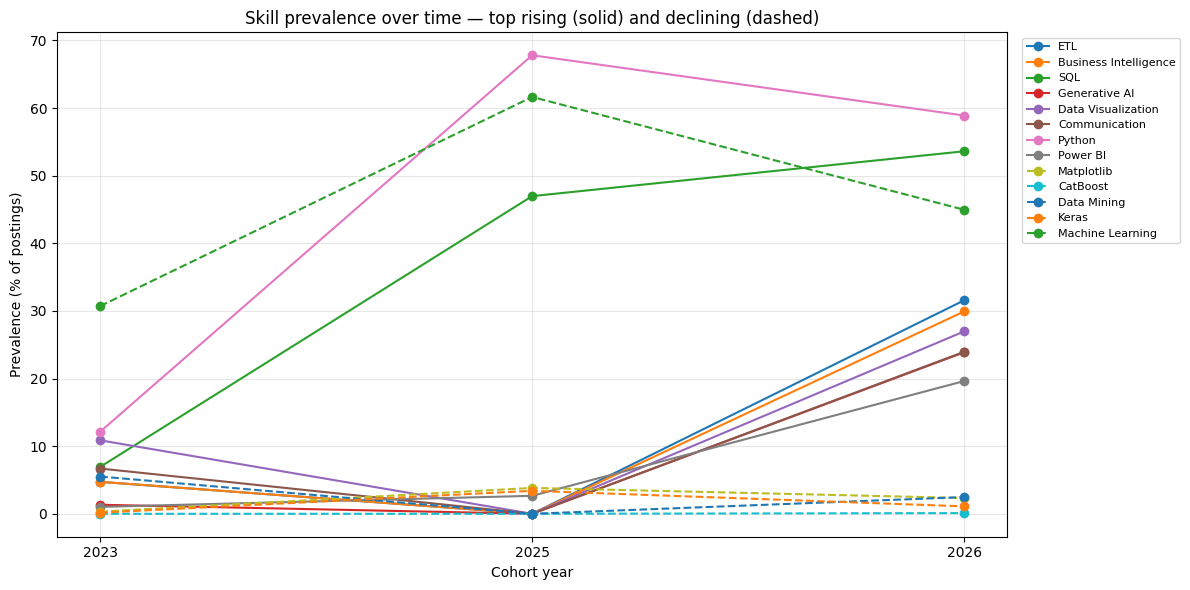

In [7]:
# ── Plot 2: Prevalence trend lines for top-N skills ───────────────────────────
top_skills_to_plot = momentum.head(8).index.tolist() + momentum.tail(5).index.tolist()
plot_cohorts = [c for c in cohort_order if c in pivot.columns]

fig, ax = plt.subplots(figsize=(12, 6))
colors_rising   = cm.get_cmap("tab10").colors

for i, skill in enumerate(top_skills_to_plot):
    if skill not in pivot.index:
        continue
    y = [pivot.loc[skill, c] if c in pivot.columns else np.nan for c in cohort_order]
    is_rising = skill in momentum.head(8).index
    color = "#2a9d8f" if is_rising else "#e76f51"
    ls = "-" if is_rising else "--"
    ax.plot(plot_cohorts, [pivot.loc[skill, c] for c in plot_cohorts], marker="o", label=skill, linestyle=ls)

ax.set_title("Skill prevalence over time — top rising (solid) and declining (dashed)")
ax.set_xlabel("Cohort year")
ax.set_ylabel("Prevalence (% of postings)")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

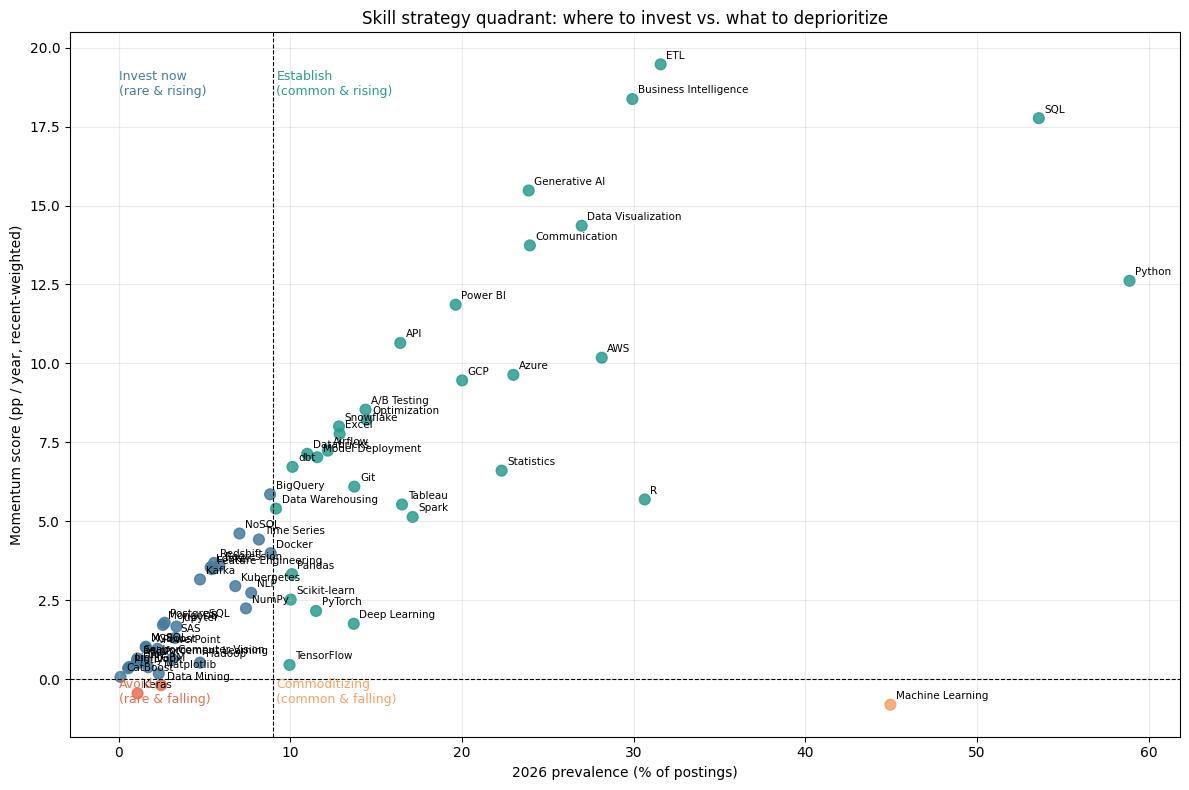

In [8]:
# ── Plot 3: 2×2 strategic quadrant ───────────────────────────────────────────
# X-axis: 2026 prevalence (how common is this skill today)
# Y-axis: momentum score (is it rising or falling)
# Quadrants: Rising+Common = "Establish" | Rising+Rare = "Invest Now"
#            Falling+Common = "Commoditizing" | Falling+Rare = "Avoid"

quad_df = momentum[["momentum_score"]].copy()
if "prev_2026" in momentum.columns:
    quad_df["prevalence_2026"] = momentum["prev_2026"]
elif "prev_2025" in momentum.columns:
    quad_df["prevalence_2026"] = momentum["prev_2025"]

quad_df = quad_df.dropna()
x_med = quad_df["prevalence_2026"].median()
y_mid = 0  # rising vs falling split at zero

fig, ax = plt.subplots(figsize=(12, 8))

colors_quad = np.where(
    (quad_df["prevalence_2026"] >= x_med) & (quad_df["momentum_score"] >= y_mid), "#2a9d8f",
    np.where(
        (quad_df["prevalence_2026"] < x_med) & (quad_df["momentum_score"] >= y_mid), "#457b9d",
        np.where(
            (quad_df["prevalence_2026"] >= x_med) & (quad_df["momentum_score"] < y_mid), "#f4a261",
            "#e76f51"
        )
    )
)

ax.scatter(quad_df["prevalence_2026"], quad_df["momentum_score"], c=colors_quad, s=60, alpha=0.85)

for skill, row in quad_df.iterrows():
    ax.annotate(skill, (row["prevalence_2026"], row["momentum_score"]),
                fontsize=7.5, xytext=(4, 4), textcoords="offset points")

ax.axhline(y_mid, color="black", linewidth=0.8, linestyle="--")
ax.axvline(x_med, color="black", linewidth=0.8, linestyle="--")

ax.text(x_med * 1.02, quad_df["momentum_score"].max() * 0.95, "Establish\n(common & rising)",  color="#2a9d8f", fontsize=9)
ax.text(0,            quad_df["momentum_score"].max() * 0.95, "Invest now\n(rare & rising)",    color="#457b9d", fontsize=9)
ax.text(x_med * 1.02, quad_df["momentum_score"].min() * 0.95, "Commoditizing\n(common & falling)", color="#f4a261", fontsize=9)
ax.text(0,            quad_df["momentum_score"].min() * 0.95, "Avoid\n(rare & falling)",         color="#e76f51", fontsize=9)

ax.set_xlabel("2026 prevalence (% of postings)")
ax.set_ylabel("Momentum score (pp / year, recent-weighted)")
ax.set_title("Skill strategy quadrant: where to invest vs. what to deprioritize")
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

## 5) Conclusion

The analysis classifies skills into four strategic buckets based on current prevalence and demand trajectory:

- **Invest now (rare & rising):** These skills are not yet ubiquitous but are gaining ground fast — prime candidates for near-term learning investment before they become table stakes.
- **Establish (common & rising):** Already widely required and still growing; essential baseline skills that every data science candidate should have.
- **Commoditizing (common & falling):** Broadly demanded today but losing differentiation over time; still worth having but unlikely to make your CV stand out.
- **Avoid (rare & falling):** Low and declining demand; deprioritize unless required for a specific target role.

**Caveat:** The three cohorts differ in geography (Glassdoor US 2023, broad 2025 dataset, TX + London 2026 scrape) and role mix, so some prevalence shifts reflect dataset composition rather than a pure market signal. The directional findings are informative, but a longitudinal panel of identical roles and geographies would be needed to draw firm causal conclusions.